# Data Visualization for the "Makeup" Project

## Data Loading

- Import the necessary libraries for data processing and visualization creation.
- Load the data file and display the list of columns.
- Display a table with selected colors for each data category.


In [1]:
# Library Imports

import pandas as pd  # For working with tabular data.
import numpy as np  # For numerical computations and arrays.
import seaborn as sns  # For creating statistical plots (heatmaps, distributions).
import matplotlib.pyplot as plt  # For basic plots (line charts, histograms, pie charts).
import plotly.graph_objects as go  # For detailed interactive graphs (3D, complex visualizations).
import plotly.express as px  # For creating interactive data visualizations.

# Load data from the CSV file.
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Display the list of columns.
print("List of columns in the DataFrame:")
print(df.columns.tolist())


List of columns in the DataFrame:
['id', 'brand', 'name', 'price', 'description', 'rating', 'category', 'product_type', 'product_colors', 'price_category', 'brand_popularity', 'category_product_type', 'brand_category_product_type']


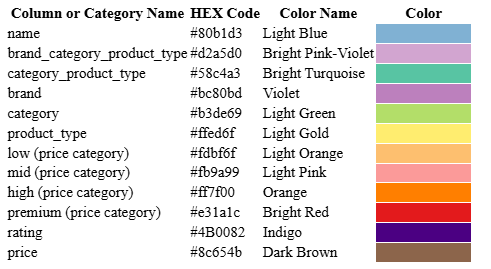

In [2]:
from IPython.display import Image, display

# Loading color images
image_path = "color_table.png"  
display(Image(filename=image_path))

## 1. Number of Product Names, Brands, Categories, and Types

- **Chart Type:**
    - `barh` (horizontal bar chart)  
Displays: **The count of unique values** for each data category.


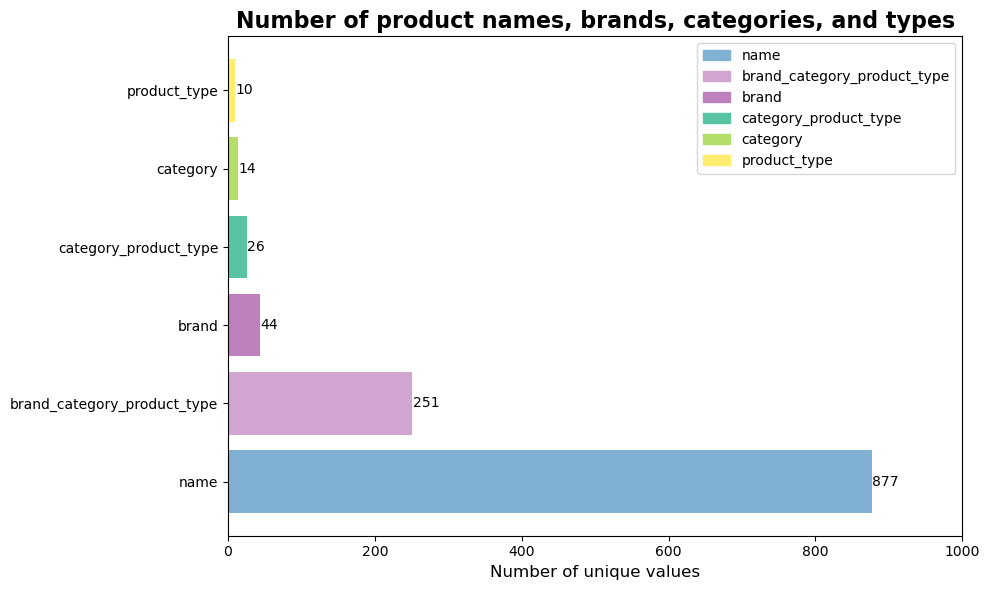

In [3]:
# 1. Number of product names, brands, categories, and types in the Makeup catalog 

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Columns and colors (updated with new colors)
columns_colors = {
    "name": "#80b1d3",  # Light blue
    "brand_category_product_type": "#d2a5d0",  # Bright pink-violet
    "brand": "#bc80bd",  # Violet
    "category_product_type": "#58c4a3",  # Bright turquoise
    "category": "#b3de69",  # Light green (updated)
    "product_type": "#ffed6f",  # Light golden (updated)
}

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Gather information for the legend
handles = []
labels = []

# Draw horizontal bars 
# (ax.barh(i, unique_count, color=color, label=column) where barh - horizontal, bar - vertical)
for i, (column, color) in enumerate(columns_colors.items()):
    unique_count = df[column].nunique()
    ax.barh(i, unique_count, color=color, label=column)
    ax.text(unique_count + 0.5, i, str(unique_count), va='center', fontsize=10, color="black")
    handles.append(plt.Rectangle((0, 0), 1, 1, color=color))
    labels.append(column)

# Configure axes and labels
ax.set_yticks(range(len(columns_colors)))
ax.set_yticklabels(list(columns_colors.keys()), fontsize=10)
ax.set_xlabel("Number of unique values", fontsize=12)
ax.set_title("Number of product names, brands, categories, and types", fontsize=16, fontweight='bold')
ax.set_xlim(0, 1000)

# Legend ordered to match the bars
ax.legend(handles, labels, loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

# 1_Number_of_unique_values


## 2. Number of Brands and Products by Combination of Category and Product Type 

- **Chart Type:** 
    - `barh` (horizontal bar chart)  
- **Displays:**  
   - **Brand** — Count of unique brands (shown on the left).  
   - **Name** — Count of unique products (shown on the right) for each combination of category and product type (`category_product_type`).  
- **Feature:** A central vertical axis separates the two categories.


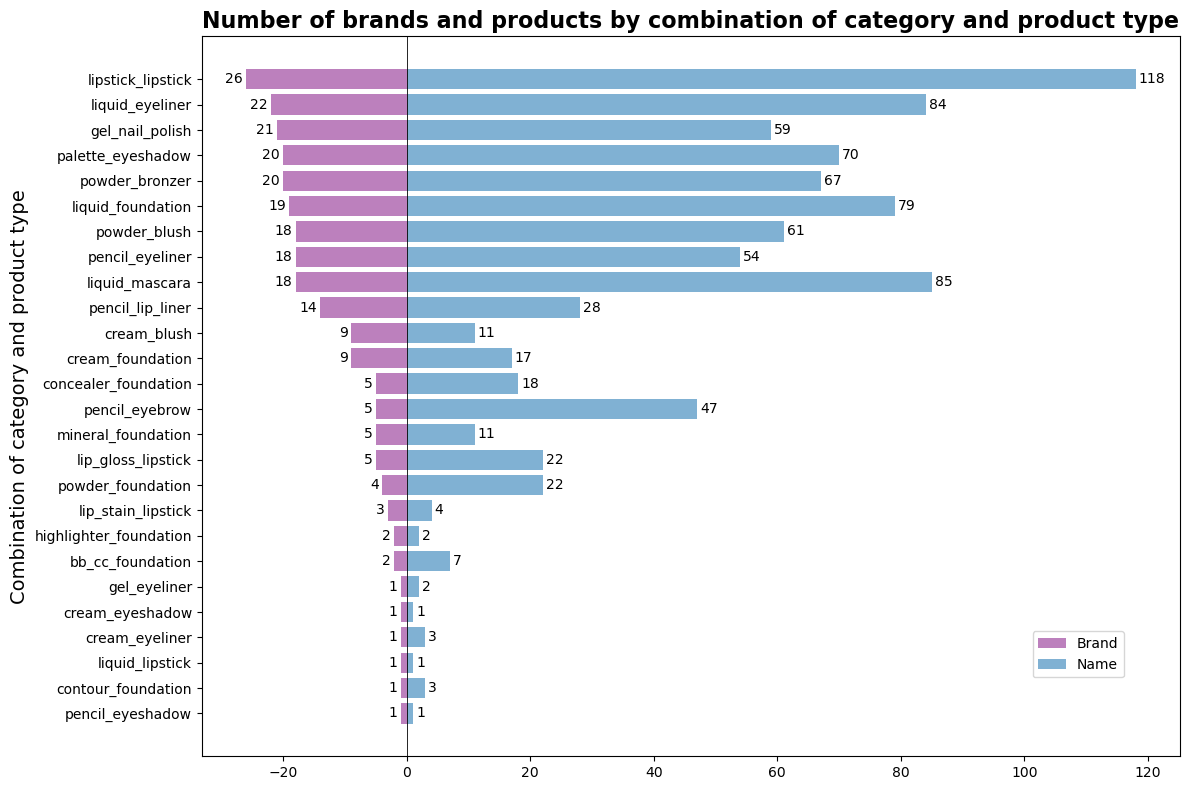

In [4]:
# 2. Number of brands and products by combination of category and product type

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from the CSV file
file_path = "makeup_valid_prices_filled_columns.csv"
data_frame = pd.read_csv(file_path)

# Count unique brands and product names for each category_product_type
brand_counts = data_frame.groupby('category_product_type')['brand'].nunique()
name_counts = data_frame.groupby('category_product_type')['name'].nunique()

# Sort by the number of brands (for better graph aesthetics)
sorted_indices = brand_counts.sort_values().index
brand_counts = brand_counts.loc[sorted_indices]
name_counts = name_counts.loc[sorted_indices]

# Values for plotting (brands → left, names → right)
brands = -brand_counts.values  # Negative values to display on the left
names = name_counts.values  # Positive values to display on the right

y_pos = np.arange(len(sorted_indices))

# Create the plot
plt.figure(figsize=(12, 8))

# Left wing (number of brands)
plt.barh(y_pos, brands, color='#bc80bd', label='Brand')  # Violet

# Right wing (number of names)
plt.barh(y_pos, names, color='#80b1d3', label='Name')  # Light blue

# Y-axis labels
plt.yticks(y_pos, sorted_indices)
plt.ylabel('Combination of category and product type', fontsize=14)

# Add labels to bars
for i, (brand, name) in enumerate(zip(brands, names)):
    plt.text(brand - 0.5, i, str(abs(brand)), va='center', ha='right', color='black')
    plt.text(name + 0.5, i, str(name), va='center', ha='left', color='black')

# Formatting
plt.axvline(0, color='black', linewidth=0.6)  # Central axis
plt.title('Number of brands and products by combination of category and product type', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', bbox_to_anchor=(0.95, 0.1))

plt.tight_layout()
plt.show()

# 2_Number_brands_products_category_product_type


## 3. Number of Products by Price Category  
## 4. Price Category Share (%)  
## 5. Price Statistics  
## 6. Dependency Between Price and Rating  

- **Chart Types:**  
   - `bar` (bar chart).  
   - `pie` (pie chart).  
   - `boxplot` (boxplot).  
   - `scatter` (scatter plot).  

- **Displays:**  
   - **Bar Chart:** Number of products in each price category.  
   - **Pie Chart:** Share of each price category as a percentage.  
   - **Boxplot:** Minimum, maximum, median price, as well as first and third quartiles of prices.  
   - **Scatter Plot:** Dependency between price and rating for products with both values specified.


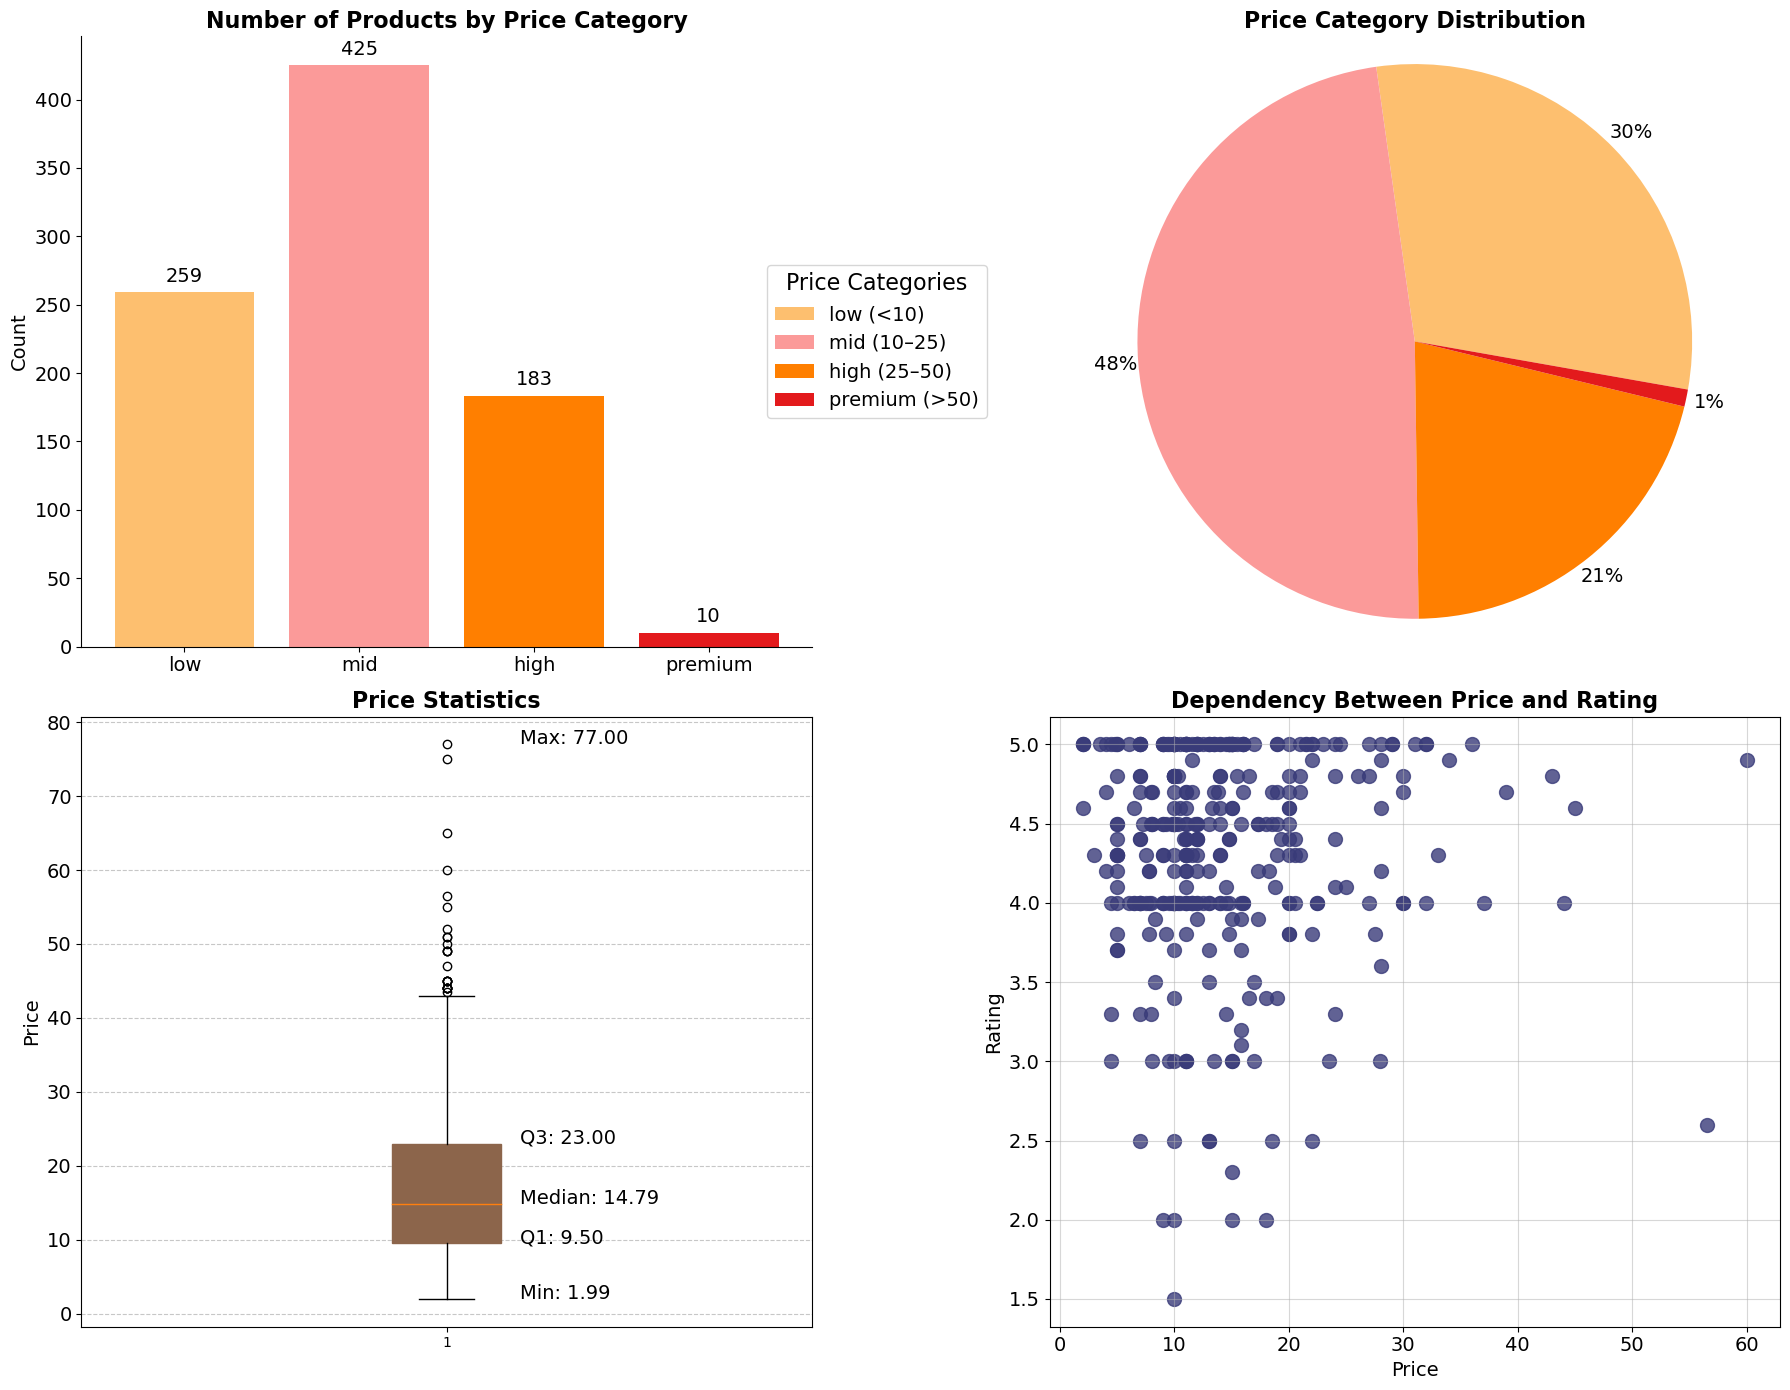

In [1]:
## 3. Number of Products by Price Category  
## 4. Price Category Share (%)  
## 5. Price Statistics   
## 6. Dependency Between Price and Rating  

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from the CSV file
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# DATA FOR PRICE CATEGORIES
price_categories_colors = {
    "low": "#fdbf6f",
    "mid": "#fb9a99",
    "high": "#ff7f00",
    "premium": "#e31a1c"
}

price_counts = df["price_category"].value_counts().reindex(price_categories_colors.keys(), fill_value=0)
price_percentages = (price_counts / price_counts.sum() * 100).round(0)

data = df["price"]
min_val = data.min()
max_val = data.max()
median_val = data.median()
q1_val = data.quantile(0.25)
q3_val = data.quantile(0.75)

df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
filtered_data = df.dropna(subset=['price', 'rating'])

# CREATE FIGURE
fig, axs = plt.subplots(2, 2, figsize=(18, 14))

# 3: Bar Chart ---
bars = axs[0, 0].bar(
    price_counts.index,
    price_counts.values,
    color=[price_categories_colors[cat] for cat in price_counts.index]
)
axs[0, 0].set_title("Number of Products by Price Category", fontsize=16, fontweight='bold')
axs[0, 0].set_ylabel("Count", fontsize=14)
axs[0, 0].tick_params(axis='x', labelsize=14)
axs[0, 0].tick_params(axis='y', labelsize=14)
axs[0, 0].spines['top'].set_visible(False)
axs[0, 0].spines['right'].set_visible(False)

for bar in bars:
    height = bar.get_height()
    axs[0, 0].text(bar.get_x() + bar.get_width() / 2, height + 5, str(int(height)),
                   ha="center", va="bottom", fontsize=14)

# 4: Pie Chart
wedges, _ = axs[0, 1].pie(
    price_percentages,
    labels=None,
    colors=[price_categories_colors[cat] for cat in price_percentages.index],
    startangle=350,
    radius=0.6
)
axs[0, 1].set_title("Price Category Distribution", fontsize=16, fontweight='bold')
axs[0, 1].axis("equal")

# Add labels near pie slices
for wedge, pct, cat in zip(wedges, price_percentages, price_counts.index):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = 0.65 * np.cos(np.radians(angle))  
    y = 0.65 * np.sin(np.radians(angle))
    axs[0, 1].text(x, y, f'{int(pct)}%', ha='center', va='center', fontsize=14, color='black')

# Legend placed to the left of the chart
legend_labels = ["low (<10)", "mid (10–25)", "high (25–50)", "premium (>50)"]
axs[0, 1].legend(
    wedges,
    legend_labels,
    title="Price Categories",
    loc="center left",
    bbox_to_anchor=(-0.4, 0.5),  # Place the legend to the left
    fontsize=14,
    title_fontsize=16
)

# 5: Boxplot
axs[1, 0].boxplot(data, patch_artist=True, boxprops=dict(facecolor="#8c654b", color="#8c654b"))
axs[1, 0].set_title("Price Statistics", fontsize=16, fontweight='bold')
axs[1, 0].set_ylabel("Price", fontsize=14)
axs[1, 0].tick_params(axis='y', labelsize=14)
axs[1, 0].grid(axis="y", linestyle="--", alpha=0.7)
axs[1, 0].text(1.1, min_val, f"Min: {min_val:.2f}", fontsize=14, color="black")
axs[1, 0].text(1.1, max_val, f"Max: {max_val:.2f}", fontsize=14, color="black")
axs[1, 0].text(1.1, median_val, f"Median: {median_val:.2f}", fontsize=14, color="black")
axs[1, 0].text(1.1, q1_val, f"Q1: {q1_val:.2f}", fontsize=14, color="black")
axs[1, 0].text(1.1, q3_val, f"Q3: {q3_val:.2f}", fontsize=14, color="black")

# 6: Scatter Plot
axs[1, 1].scatter(filtered_data['price'], filtered_data['rating'], s=100, color="#393b79", alpha=0.8)
axs[1, 1].set_title("Dependency Between Price and Rating", fontsize=16, fontweight='bold')
axs[1, 1].set_xlabel("Price", fontsize=14)
axs[1, 1].set_ylabel("Rating", fontsize=14)
axs[1, 1].tick_params(axis='x', labelsize=14)
axs[1, 1].tick_params(axis='y', labelsize=14)
axs[1, 1].grid(alpha=0.5)

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.5, wspace=0.4)  # Vertical and horizontal spacing
plt.tight_layout()


plt.show()

# 3_4_5_6_Price


## 7. Distribution of Product Ratings  
## 8. Proportion of Products with and without Ratings  
## 9. How many types, categories, and brands have ratings?


- **Chart Types:**  
    - `kdeplot` (Kernel Density Estimation plot).  
    - `pie` (Pie chart).  
    - `bar` (Stacked bar chart).  

- **Displays:**  
    - Distribution of product ratings in the catalog.  
    - Proportion of products with and without ratings, shown as percentages.  
    - Count of types, categories, and brands with ratings, mixed ratings, or no ratings.


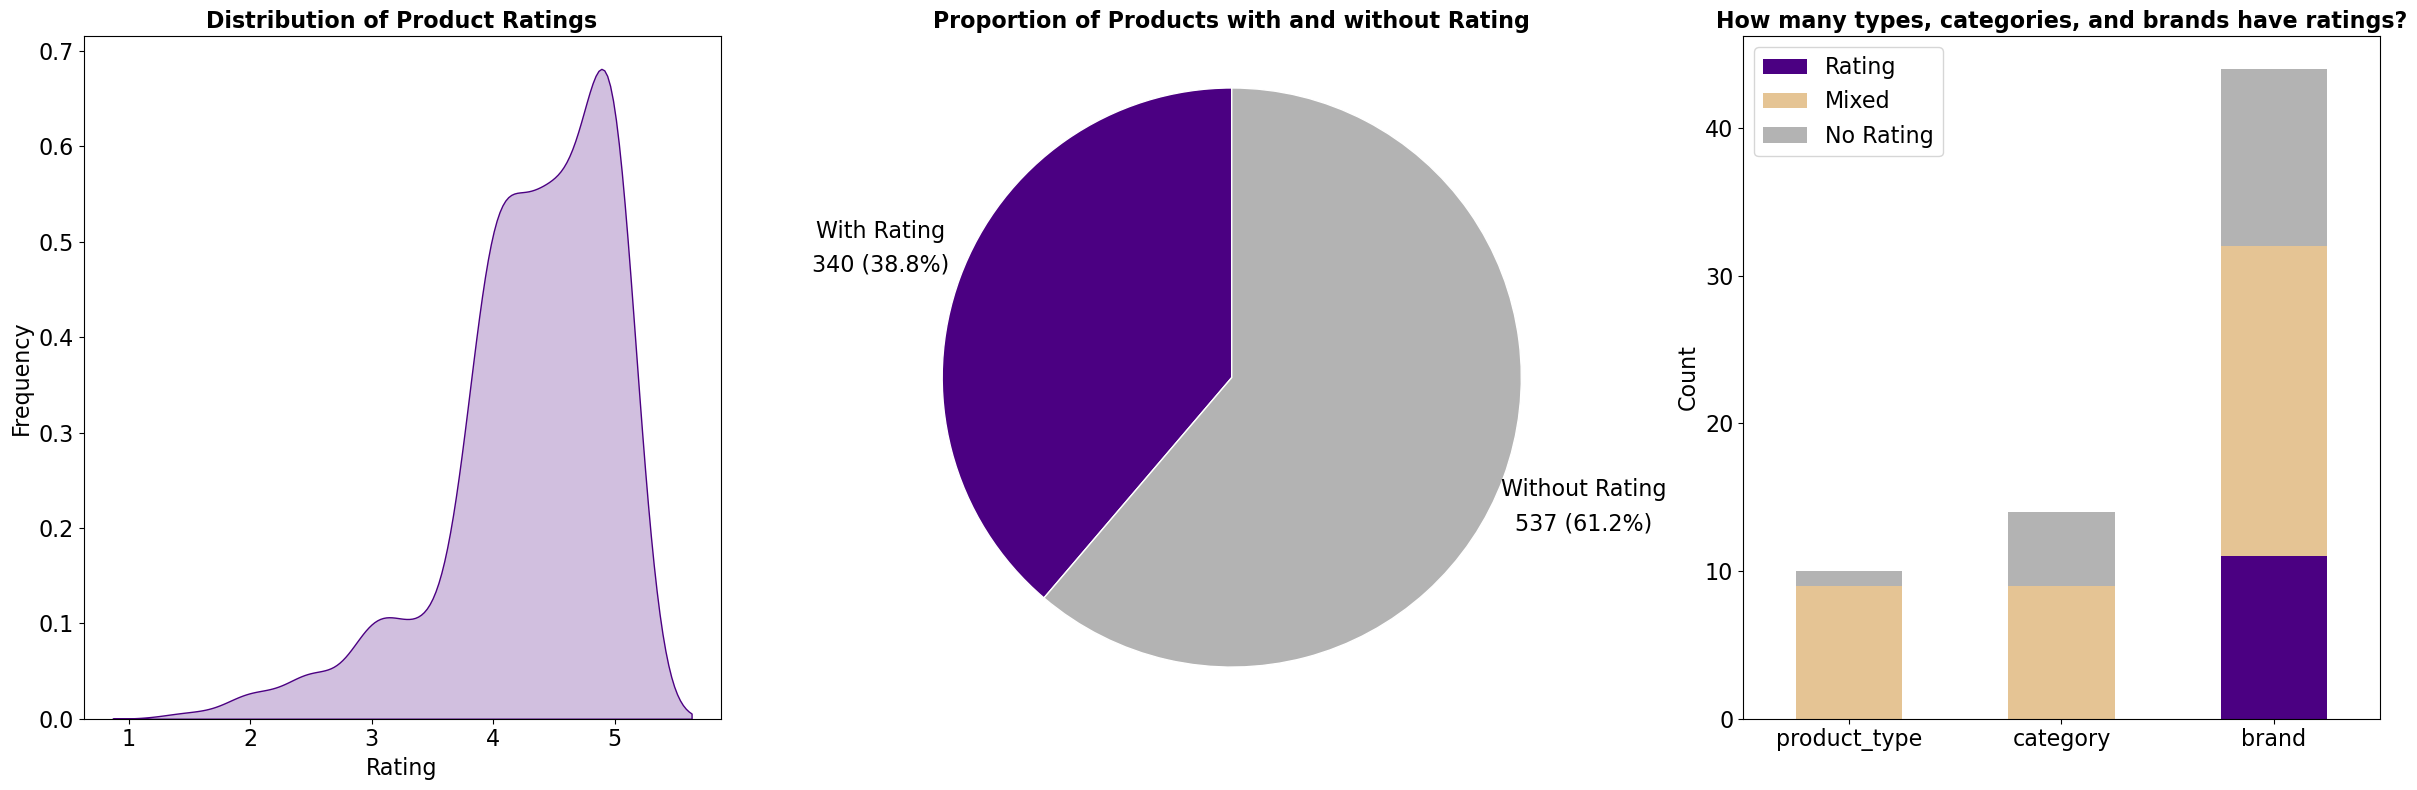

In [5]:
## 7. Distribution of Product Ratings 
## 8. Proportion of Products with and without Rating 
## 9. How many types, categories, and brands have ratings?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Ensure 'rating' is numerical
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
filtered_ratings = df.dropna(subset=['rating'])

# Calculate the number of entries with and without ratings
with_rating = filtered_ratings.shape[0]
without_rating = df.shape[0] - with_rating

# Data for the pie chart
labels = ['With Rating', 'Without Rating']
sizes = [with_rating, without_rating]
colors = ['#4B0082', '#b3b3b3']  # Indigo and gray

# Function to determine the status
def determine_status(sub_df):
    total = len(sub_df)
    rated = sub_df['rating'].notna().sum()
    no_rating = sub_df['rating'].isna().sum()
    if rated == total:
        return "rating"
    elif no_rating == total:
        return "no_rating"
    else:
        return "mixed"

# Function to count statuses
def count_statuses(df, column_name):
    statuses = df.groupby(column_name).apply(determine_status)
    counts = statuses.value_counts()
    return counts

# Build a summary table
summary = pd.DataFrame({
    'product_type': count_statuses(df, 'product_type'),
    'category': count_statuses(df, 'category'),
    'brand': count_statuses(df, 'brand')
}).fillna(0).astype(int)

# Fixed order of statuses
summary = summary.reindex(['rating', 'mixed', 'no_rating'])

# Create a figure with three plots on one plane
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Plot 7: Distribution of ratings
sns.kdeplot(
    data=filtered_ratings,
    x='rating',
    fill=True,
    color="#4B0082",
    ax=axes[0]
)
axes[0].set_title("Distribution of Product Ratings", fontsize=16, fontweight='bold')  # Bold title
axes[0].set_xlabel("Rating", fontsize=16, color='black')  # X-axis labels
axes[0].set_ylabel("Frequency", fontsize=16, color='black')  # Y-axis labels
axes[0].tick_params(axis='x', labelsize=16, labelcolor='black')  # Enlarged X-axis ticks
axes[0].tick_params(axis='y', labelsize=16, labelcolor='black')  # Enlarged Y-axis ticks

# Plot 8: Pie chart of proportions with/without rating
wedges, _ = axes[1].pie(
    sizes,
    labels=None,
    startangle=90,
    colors=colors,
    radius=0.85,  # Reduced circle size
    wedgeprops=dict(edgecolor='white')
)
for i, wedge in enumerate(wedges):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 1.1 * math.cos(math.radians(angle))  # Reduced label radius
    y = 1.1 * math.sin(math.radians(angle))
    axes[1].text(x, y + 0.05, labels[i], ha='center', va='center', fontsize=16, color='black')  # Labels are not bold
    percent = f"{sizes[i] / sum(sizes) * 100:.1f}%"
    axes[1].text(x, y - 0.05, f"{sizes[i]} ({percent})", ha='center', va='center', fontsize=16, color='black')  # Labels are not bold
axes[1].set_title("Proportion of Products with and without Rating", fontsize=16, fontweight='bold')  # Bold title
axes[1].axis('equal')

# Plot 9: Stacked bar chart with legend in the upper left corner
summary.T.plot(
    kind='bar',
    stacked=True,
    color=['#4B0082', '#e5c494', '#b3b3b3'],
    ax=axes[2]
)
axes[2].set_xticklabels(summary.columns, rotation=0, fontsize=16, color='black')  
axes[2].set_title("How many types, categories, and brands have ratings?", fontsize=16, fontweight='bold')  
axes[2].set_ylabel("Count", fontsize=16, color='black')  
axes[2].tick_params(axis='x', labelsize=16, labelcolor='black')  
axes[2].tick_params(axis='y', labelsize=16, labelcolor='black')  

# Legend in the upper left corner of the plot
legend = axes[2].legend(["Rating", "Mixed", "No Rating"], loc='upper left', fontsize=16)

# Layout adjustment for all plots
plt.tight_layout()
plt.show()

# 7_8_9_Rating


## 10. Product Type: Count of Products, Average Rating, and Average Price  

- **Chart Types:**  
   - Bars: `bar` (bar chart).  
   - Lines: `line` (line graph).  
- **Displays:**  
   - **Bars:** Number of unique products for each product type.  
   - **Lines (Average Rating):** Shows the trend of average ratings for each product type.  
   - **Lines (Average Price):** Displays the average price for each product type.


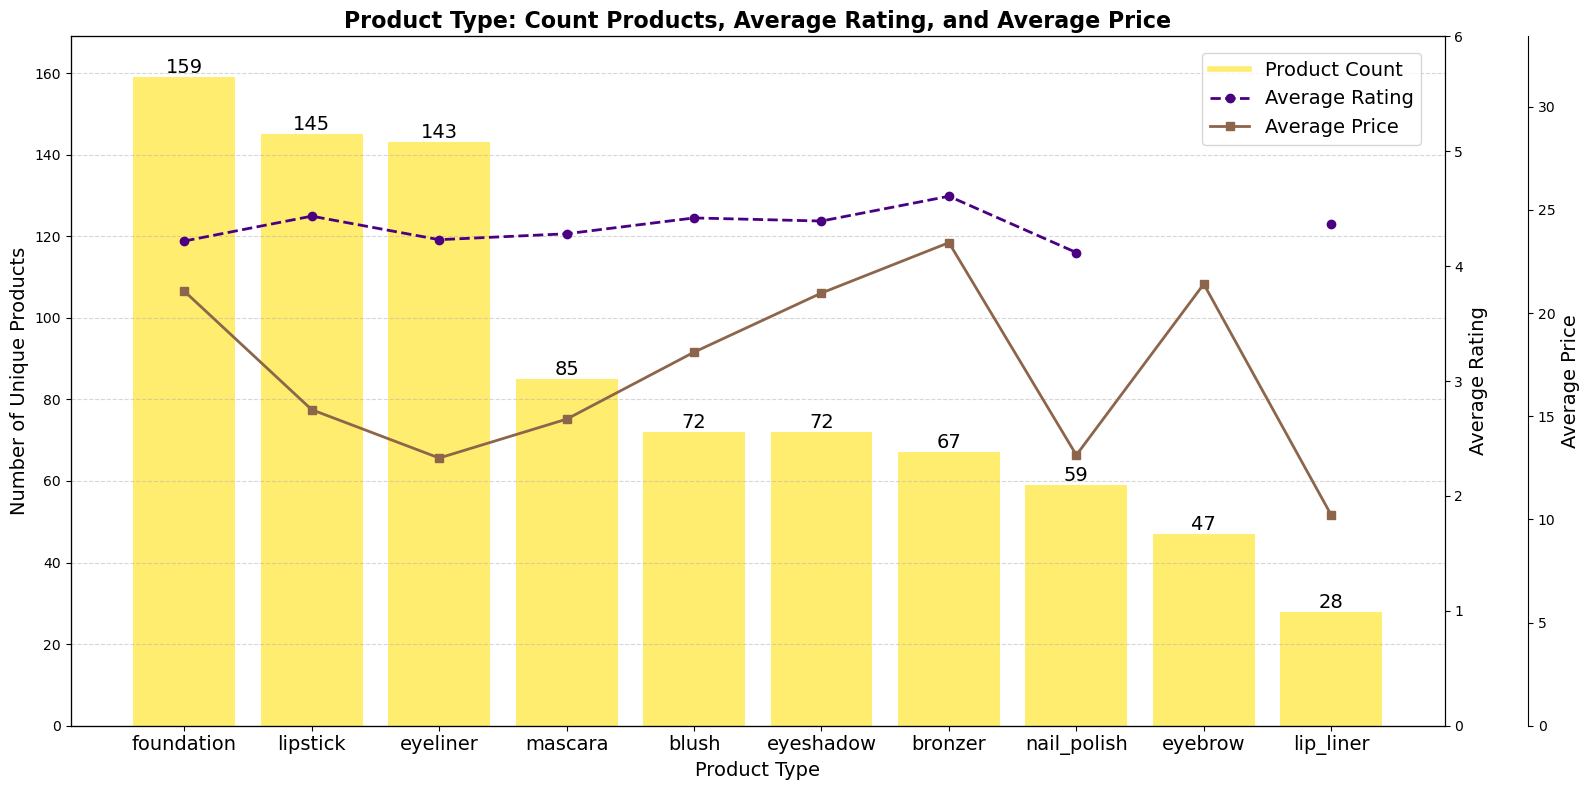

In [6]:
# 10. Product Type: Count Products, Average Rating, and Average Price

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Group by product type and calculate the required metrics
grouped = df.groupby('product_type').agg({
    'id': 'nunique',  # Count of unique products
    'rating': 'mean',  # Average rating
    'price': 'mean'    # Average price
}).reset_index()

# Sort by the number of products in descending order
grouped = grouped.sort_values(by='id', ascending=False)

# Prepare data for the chart
types = grouped['product_type']
counts = grouped['id']
avg_ratings = grouped['rating']
avg_prices = grouped['price']

# Colors for the chart
bar_color = '#ffed6f'      # Light golden
rating_color = '#4B0082'   # Indigo
price_color = '#8c654b'    # Brown

# Create the canvas
fig, ax1 = plt.subplots(figsize=(16, 8))

# Bars — Number of unique products
bars = ax1.bar(types, counts, color=bar_color)
ax1.set_xlabel("Product Type", fontsize=14, color='black')  # X-axis label
ax1.set_ylabel("Number of Unique Products", fontsize=14, color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(range(len(types)))
ax1.set_xticklabels(types, rotation=0, ha='center', fontsize=14, color='black')  # Enlarged font size for X-axis labels
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, counts.max() + 10)

# Secondary Y-axis — Average rating
ax2 = ax1.twinx()
ax2.plot(types, avg_ratings, color=rating_color, marker='o', linestyle='--', linewidth=2, label='Average Rating')
ax2.set_ylabel("Average Rating", fontsize=14, color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 6)

# Tertiary Y-axis — Average price
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(types, avg_prices, color=price_color, marker='s', linestyle='-', linewidth=2, label='Average Price')
ax3.set_ylabel("Average Price", fontsize=14, color='black')
ax3.tick_params(axis='y', labelcolor='black')
ax3.set_ylim(0, avg_prices.max() + 10)

# Legend
bars_patch = plt.Line2D([0], [0], color=bar_color, lw=4)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
legend_elements = [bars_patch] + lines1 + lines2
legend_labels = ["Product Count"] + labels1 + labels2
ax1.legend(legend_elements, legend_labels, loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=14)

# Add text above bars
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  
        bar.get_height(),  
        f'{int(bar.get_height())}',  
        ha='center',  
        va='bottom',  
        fontsize=14,  
        color='black' 
    )

# Chart title
plt.title("Product Type: Count Products, Average Rating, and Average Price", fontsize=16, fontweight='bold')

# Set black color for all axes
for spine in ax1.spines.values():
    spine.set_color('black')
for spine in ax2.spines.values():
    spine.set_color('black')
for spine in ax3.spines.values():
    spine.set_color('black')

plt.tight_layout()
plt.show()

# 10_Product_Type


## 11. Category: Count Products, Average Rating, and Average Price

- **Chart Types:**  
   - Bars: `bar` (bar chart).  
   - Lines: `line` (line graph).  
- **Displays:**  
   - **Bars:** Number of unique products for each category.  
   - **Lines (Average Rating):** Shows the trend of average ratings for each category.  
   - **Lines (Average Price):** Displays the average price for each category.


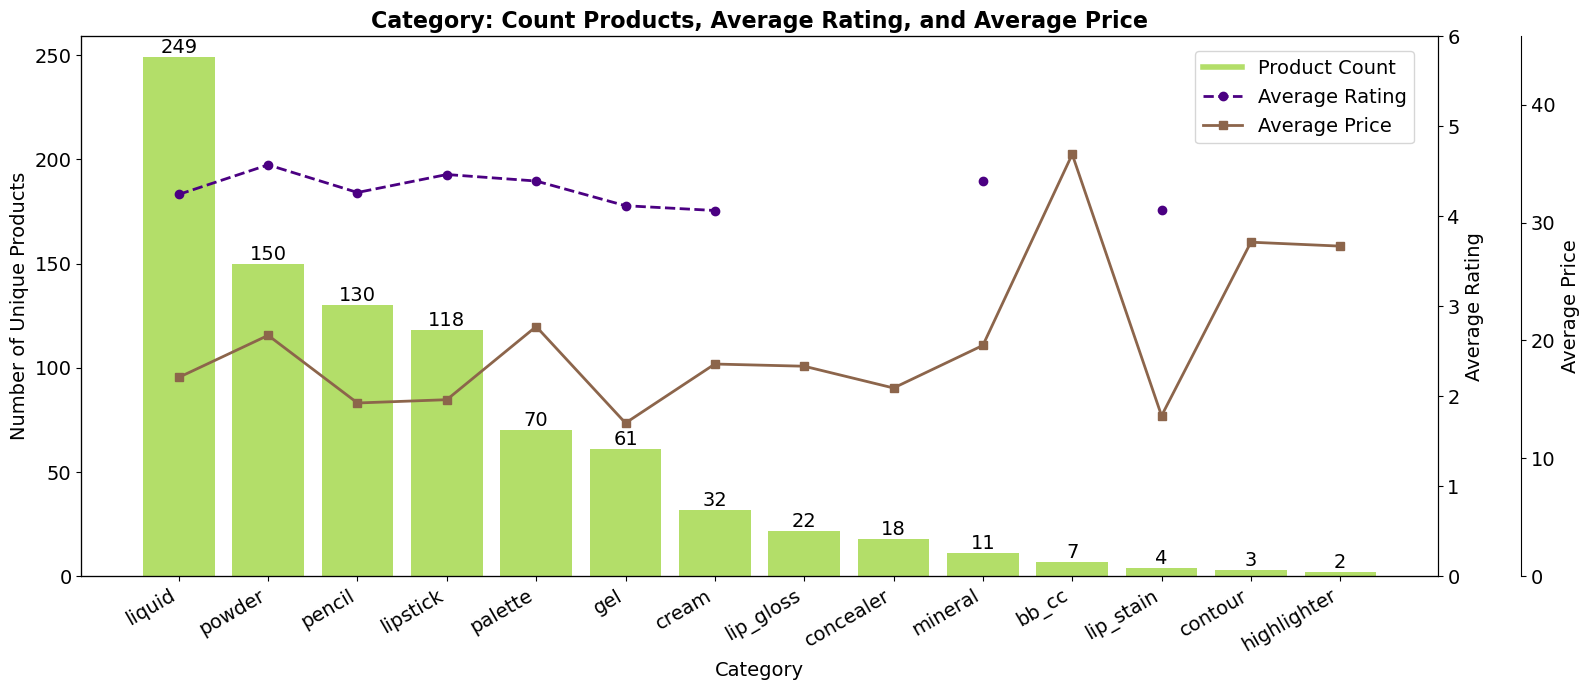

In [7]:
# 11. Category: Count Products, Average Rating, and Average Price

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Group by category and calculate required metrics
grouped = df.groupby('category').agg({
    'id': 'nunique',  # Count of unique products
    'rating': 'mean',  # Average rating
    'price': 'mean'    # Average price
}).reset_index()

# Sort by the number of products in descending order
grouped = grouped.sort_values(by='id', ascending=False)

# Prepare data for the plot
categories = grouped['category']
counts = grouped['id']
avg_ratings = grouped['rating']
avg_prices = grouped['price']

# Colors for the plot
bar_color = '#b3de69'  # Light green for category
rating_color = '#4B0082'  # Indigo
price_color = '#8c654b'  # Brown

# Create the plot
fig, ax1 = plt.subplots(figsize=(16, 7))

# Bars — number of unique products
bars = ax1.bar(categories, counts, color=bar_color)
ax1.set_xlabel("Category", fontsize=14, color='black')  # X-axis label
ax1.set_ylabel("Number of Unique Products", fontsize=14, color='black')  # Y-axis label
ax1.tick_params(axis='y', labelsize=14, labelcolor='black')  # Increase font size for Y-axis text
ax1.set_xticks(range(len(categories)))
ax1.set_xticklabels(categories, rotation=30, ha='right', fontsize=14, color='black')  
ax1.set_ylim(0, counts.max() + 10)

# Secondary Y-axis — Average Rating
ax2 = ax1.twinx()
ax2.plot(categories, avg_ratings, color=rating_color, marker='o', linestyle='--', linewidth=2, label='Average Rating')
ax2.set_ylabel("Average Rating", fontsize=14, color='black')  
ax2.tick_params(axis='y', labelsize=14, labelcolor='black')  
ax2.set_ylim(0, 6)

# Tertiary Y-axis — Average Price
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(categories, avg_prices, color=price_color, marker='s', linestyle='-', linewidth=2, label='Average Price')
ax3.set_ylabel("Average Price", fontsize=14, color='black')  
ax3.tick_params(axis='y', labelsize=14, labelcolor='black')  
ax3.set_ylim(0, avg_prices.max() + 10)

# Legend
bars_patch = plt.Line2D([0], [0], color=bar_color, lw=4)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
legend_elements = [bars_patch] + lines1 + lines2
legend_labels = ["Product Count"] + labels1 + labels2
ax1.legend(legend_elements, legend_labels, loc='upper right', bbox_to_anchor=(0.99, 0.99), fontsize=14)  

# Add text above bars
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{int(bar.get_height())}',
        ha='center',
        va='bottom',
        fontsize=14,  
        color='black'
    )

# Title
plt.title("Category: Count Products, Average Rating, and Average Price", fontsize=16, fontweight='bold')  

# Set black color for all axes
for spine in ax1.spines.values():
    spine.set_color('black')
for spine in ax2.spines.values():
    spine.set_color('black')
for spine in ax3.spines.values():
    spine.set_color('black')

plt.tight_layout()
plt.show()

# 11_Category


## 12. Connections Between Product Types and Categories

- **Chart Type:**  
    - `Sankey Diagram` (Sankey chart).  
- **Displays:**  
   - The interrelation between product types and their categories.  
   - The diagram illustrates how product volumes are distributed from each type to their respective categories, using **line width to represent the quantitative relationship** between product types and categories.  
   - Labels include product type and category names, along with their total counts.


In [8]:
# 12. Connections Between Product Types and Categories

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px  

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Grouping
df_grouped = df.groupby(['product_type', 'category']).size().reset_index(name='count')
df_grouped = df_grouped[df_grouped['product_type'] != df_grouped['category']]  # Remove loops

# Create labels with product_type and category names (including counts)
product_counts = df_grouped.groupby('product_type')['count'].sum().to_dict()
category_counts = df_grouped.groupby('category')['count'].sum().to_dict()

product_types = list(product_counts.keys())
categories = list(category_counts.keys())
labels = [f"{pt} ({product_counts[pt]})" for pt in product_types] + [f"{cat} ({category_counts[cat]})" for cat in categories]

# Define source and target indices
source_indices = df_grouped['product_type'].apply(lambda x: product_types.index(x))
target_indices = df_grouped['category'].apply(lambda x: categories.index(x) + len(product_types))

# Link colors based on category
category_color_map = {cat: '#b3de69' if cat == 'category' else px.colors.qualitative.Plotly[i % 10] for i, cat in enumerate(categories)}
link_colors = df_grouped['category'].apply(lambda x: category_color_map[x]).tolist()

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=20,
        thickness=30,
        line=dict(color="black", width=0.5),
        label=labels,
        color="rgba(230,230,230,0.6)",
        hoverlabel=dict(font=dict(size=14))
    ),
    link=dict(
        source=source_indices,
        target=target_indices,
        value=df_grouped['count'],
        color=link_colors,
        hoverlabel=dict(font=dict(size=13))
    )
)])

# Styling
fig.update_layout(
    title=dict(
        text="<b>Connections Between Product Types and Categories</b>",  # Add bold HTML title
        font=dict(size=16),
        x=0.5,  # Center the title
        xanchor='center'
    ),
    font=dict(size=14),
    height=750,
    width=1100,
    margin=dict(l=50, r=150, t=80, b=40),
    annotations=[
        dict(x=0.01, y=1.05, text="Product Types", showarrow=False, font=dict(size=14)),
        dict(x=0.99, y=1.05, text="Categories", showarrow=False, xanchor='right', font=dict(size=14))
    ]
)

fig.show()

# 12_Product_Types_and_Categories_Sankey


In [ ]:
## 13. Brands by Categories and Product Types with Ratings

- **Chart Type:**  
    - `treemap` (Treemap chart).  
- **Displays:**  
   - Hierarchical structure of brands organized by categories and product types.  
   - Rating values for each element within the hierarchy.  
   - Higher ratings are shown using a color gradient from orange to red, while lower ratings are represented by dark blue, and mid-range ratings are in yellow-green tones.


In [9]:
# 13. Brands by Categories and Product Types with Ratings 

import pandas as pd
import plotly.express as px

import plotly.io as pio
pio.renderers.default = "notebook"  # or "browser"

# Load the data
df = pd.read_csv("makeup_valid_prices_filled_columns.csv")
df = df[df['rating'].notna()]  # Filter rows with non-missing ratings

# Build the treemap
fig = px.treemap(
    df,
    path=['brand', 'product_type', 'category'],  # Hierarchy: brand → product type → category
    values='rating',  # Use 'rating' for sizing (can be swapped with 'price')
    color='rating',
    color_continuous_scale='Turbo',  # Gradient scale from Turbo palette
    title="Treemap of Brands, Product Types, and Categories",
    width=1000,
    height=700
)

# color_continuous_scale='Inferno'  # Replace 'Plasma' with 'Inferno', 'Viridis', 'Blues', or another palette

# Update style
fig.update_traces(root_color="white", textfont=dict(size=14))  # Set root color and font size

fig.update_layout(
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='black', size=16),
    title=dict(
        text="Brands by Categories and Product Types with Ratings",
        font=dict(size=24, color='black'),
        x=0.1  # Adjust title alignment (0 to 1)
    )
)

fig.show()

# 13_Brands_Categories_Product_Type_Ratings_Treemap


## 14. All Brands: Number of Products, Average Rating, and Average Price

- **Chart Types:**  
   - Bars: `bar` (bar chart).  
   - Lines: `line` (line graph).  
- **Displays:**  
   - **Bars:** Number of unique products for each brand.  
   - **Lines (Average Rating):** Shows the trend of average ratings for each brand.  
   - **Lines (Average Price):** Displays the average price for each brand.


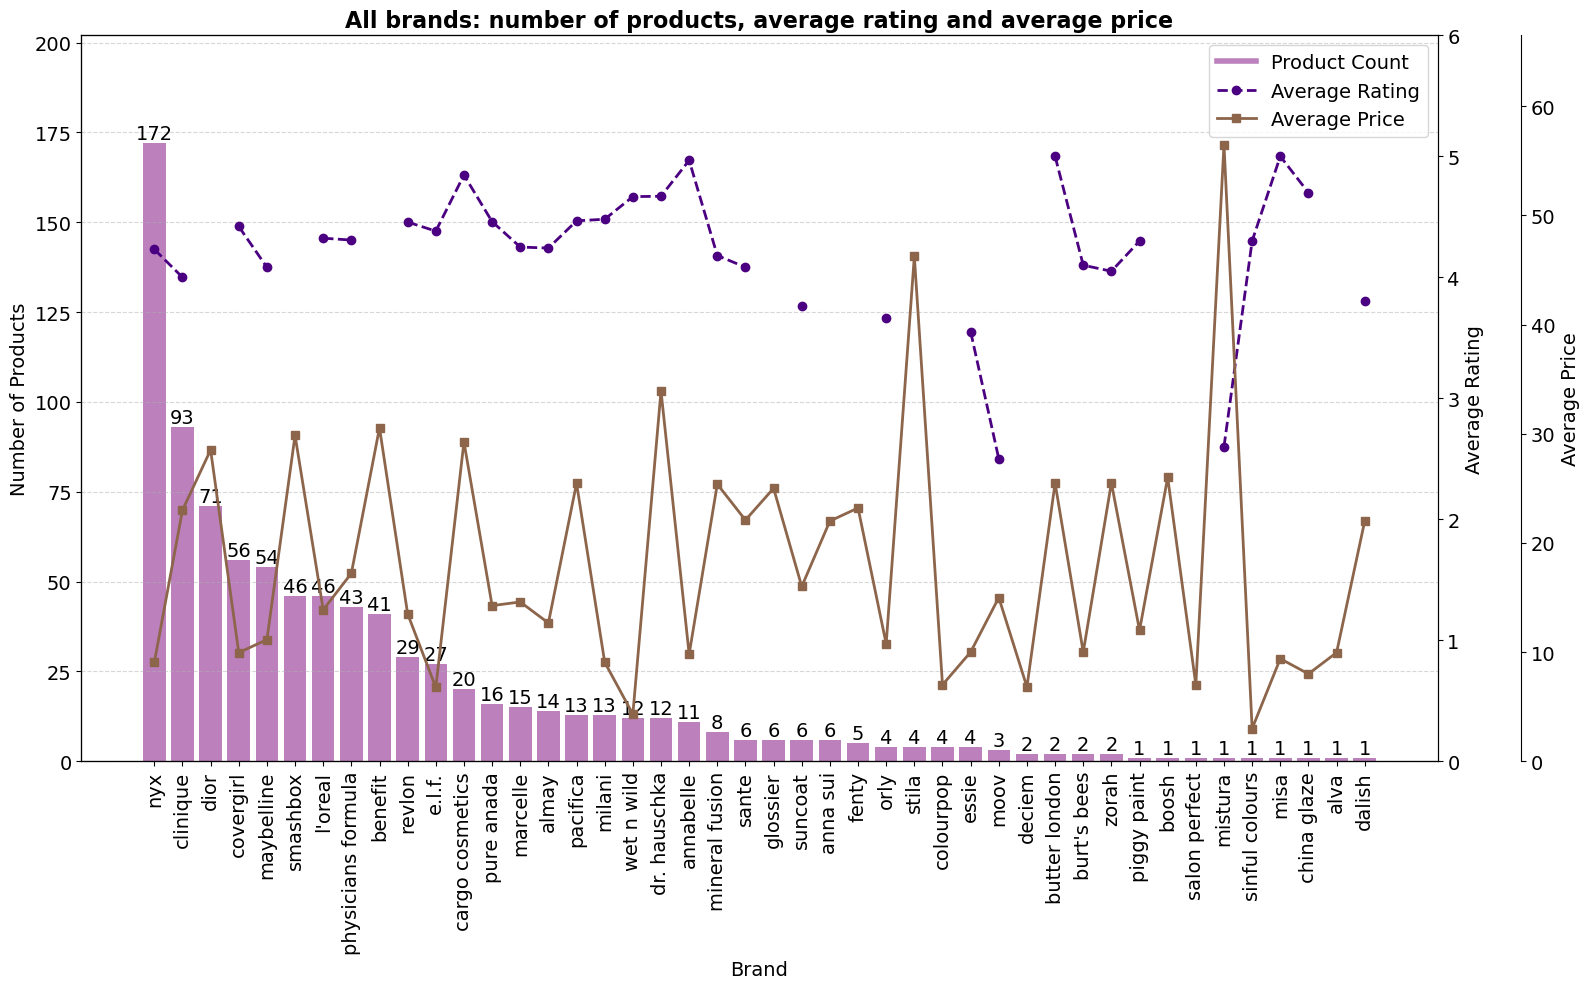

In [10]:
## 14. All brands: number of products, average rating and average price 

import pandas as pd
import matplotlib.pyplot as plt

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Group by brand and calculate required metrics
grouped = df.groupby('brand').agg({
    'id': 'nunique',     # Number of unique products
    'rating': 'mean',    # Average rating
    'price': 'mean'      # Average price
}).reset_index()

# Sort by the number of products
grouped = grouped.sort_values(by='id', ascending=False)

# Prepare data for the chart
types = grouped['brand']
counts = grouped['id']
avg_ratings = grouped['rating']
avg_prices = grouped['price']

# Colors
bar_color = '#bc80bd'  # Violet
rating_color = '#4B0082'  # Dark violet
price_color = '#8c654b'  # Brown

# Create the chart
fig, ax1 = plt.subplots(figsize=(16, 10))

# Bar chart for product count
bars = ax1.bar(types, counts, color=bar_color)
ax1.set_xlabel("Brand", fontsize=14, color='black')  
ax1.set_ylabel("Number of Products", fontsize=14, color='black')  
ax1.tick_params(axis='x', labelsize=14, labelcolor='black')  
ax1.tick_params(axis='y', labelsize=14, labelcolor='black')  
ax1.set_xticks(range(len(types)))
ax1.set_xticklabels(types, rotation=90, ha='center', fontsize=14, color='black')  
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.set_ylim(0, counts.max() + 30)

# Secondary Y-axis — Average Rating
ax2 = ax1.twinx()
ax2.plot(types, avg_ratings, color=rating_color, marker='o', linestyle='--', linewidth=2, label='Average Rating')
ax2.set_ylabel("Average Rating", fontsize=14, color='black')  
ax2.tick_params(axis='y', labelsize=14, labelcolor='black')  
ax2.set_ylim(0, 6)

# Tertiary Y-axis — Average Price
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(types, avg_prices, color=price_color, marker='s', linestyle='-', linewidth=2, label='Average Price')
ax3.set_ylabel("Average Price", fontsize=14, color='black')  
ax3.tick_params(axis='y', labelsize=14, labelcolor='black')  
ax3.set_ylim(0, avg_prices.max() + 10)

# Legend
bars_patch = plt.Line2D([0], [0], color=bar_color, lw=4)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
legend_elements = [bars_patch] + lines1 + lines2
legend_labels = ["Product Count"] + labels1 + labels2
ax1.legend(legend_elements, legend_labels, loc='upper right', bbox_to_anchor=(1, 1), fontsize=14)  

# Add text above bars
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  
        bar.get_height(),  
        f'{int(bar.get_height())}',  
        ha='center',  
        va='bottom',  
        fontsize=14,  
        color='black'  
    )

# Title
plt.title("All brands: number of products, average rating and average price", fontsize=16, fontweight='bold')  

# Set black for all axes
for spine in ax1.spines.values():
    spine.set_color('black')
for spine in ax2.spines.values():
    spine.set_color('black')
for spine in ax3.spines.values():
    spine.set_color('black')

plt.tight_layout()
plt.show()

# 14_All_brands


## 15. Coverage of Top 20 Brands in Product Distribution  
## 16. Visualization of Excluded Product  

- **Chart Types:**  
   - `donut chart` (Donut chart).  
   - `pie chart` (Pie chart).  
- **Displays:**  
   - The proportion of products offered by the top 20 brands compared to the rest of the products in the dataset.  
   - The number of categories, product types, and category-product types within the top 20 brands.  
   - Visualization of category-product types (`Category_product_type`) not included within the top 20 brands.


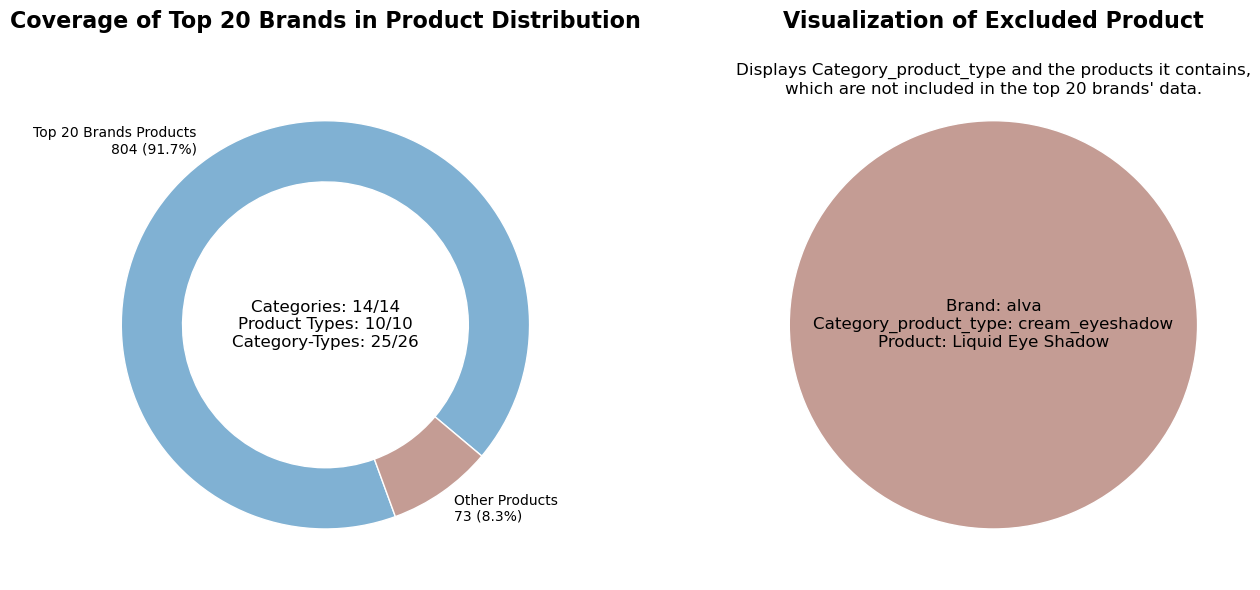

In [11]:
# 15. Coverage of Top 20 Brands in Product Distribution  
# 16. Visualization of Excluded Product  

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Calculate the top 20 brands and their product counts
brand_counts = df['brand'].value_counts()
top_20_brands = brand_counts.head(20)
total_products = df['id'].count()
top_20_total_products = top_20_brands.sum()
percentage_top_20_products = (top_20_total_products / total_products) * 100

# Calculate the number of categories, product types, and category-product types for the top 20 brands
categories_count_top_20 = len(df[df['brand'].isin(top_20_brands.index)]['category'].unique())
product_types_count_top_20 = len(df[df['brand'].isin(top_20_brands.index)]['product_type'].unique())
category_product_types_count_top_20 = len(df[df['brand'].isin(top_20_brands.index)]['category_product_type'].unique())
total_categories = len(df['category'].unique())
total_product_types = len(df['product_type'].unique())
total_category_product_types = len(df['category_product_type'].unique())

# Prepare labels for the first chart
top_20_label = f"Top 20 Brands Products\n{top_20_total_products} ({percentage_top_20_products:.1f}%)"
other_label = f"Other Products\n{total_products - top_20_total_products} ({100 - percentage_top_20_products:.1f}%)"

# Identify excluded category-product types
top_20_category_product_types = df[df['brand'].isin(top_20_brands.index)]['category_product_type'].unique()
all_category_product_types = df['category_product_type'].unique()
excluded_category_product_types = set(all_category_product_types) - set(top_20_category_product_types)

excluded_data = df[df['category_product_type'].isin(excluded_category_product_types)]
excluded_brands = excluded_data['brand'].value_counts()
excluded_brands = excluded_brands[excluded_brands == 1].index.tolist()

result_table = excluded_data[excluded_data['brand'].isin(excluded_brands)][['brand', 'category_product_type', 'id', 'name']]
brand = result_table['brand'].iloc[0]
category_product_type = result_table['category_product_type'].iloc[0]
product_name = result_table['name'].iloc[0]

# Create the two charts side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First chart: donut chart for top 20 brands
axes[0].pie(
    [percentage_top_20_products, 100 - percentage_top_20_products],
    labels=[top_20_label, other_label],
    startangle=320,
    colors=['#80b1d3', '#c49c94'],
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}
)
axes[0].set_title("Coverage of Top 20 Brands in Product Distribution", fontsize=16, pad=30, fontweight='bold')

# Add text inside the first chart for additional details
central_text = (
    f"Categories: {categories_count_top_20}/{total_categories}\n"
    f"Product Types: {product_types_count_top_20}/{total_product_types}\n"
    f"Category-Types: {category_product_types_count_top_20}/{total_category_product_types}"
)
axes[0].text(0, 0, central_text, fontsize=12, ha='center', va='center')

# Second chart: filled circle for excluded product details
axes[1].pie(
    [1],
    colors=['#c49c94'],
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title("Visualization of Excluded Product", fontsize=16, pad=30, fontweight='bold') 
axes[1].text(
    0.5, 0.98,  
    "Displays Category_product_type and the products it contains,\nwhich are not included in the top 20 brands' data.",
    fontsize=12,
    ha='center',
    va='center',
    transform=axes[1].transAxes
)

# Add text inside the second chart for excluded product details
central_text_excluded = (
    f"Brand: {brand}\nCategory_product_type: {category_product_type}\nProduct: {product_name}"
)
axes[1].text(0, 0, central_text_excluded, fontsize=12, ha='center', va='center', color='black')

# Display the charts
plt.tight_layout()
plt.show()

# 15_16_Top_20_Brands_in_Product


## 17. Top 20 Brands Offering the Most Products  

- **Chart Types:**  
   - Bars: `bar` (bar chart).  
   - Lines: `line` (line graphs).  
- **Displays:**  
   - **Bars:** Number of products offered by each of the top 20 brands.  
   - **Dashed Line:** Average rating of products from each brand.  
   - **Solid Line:** Average price of products from each brand.


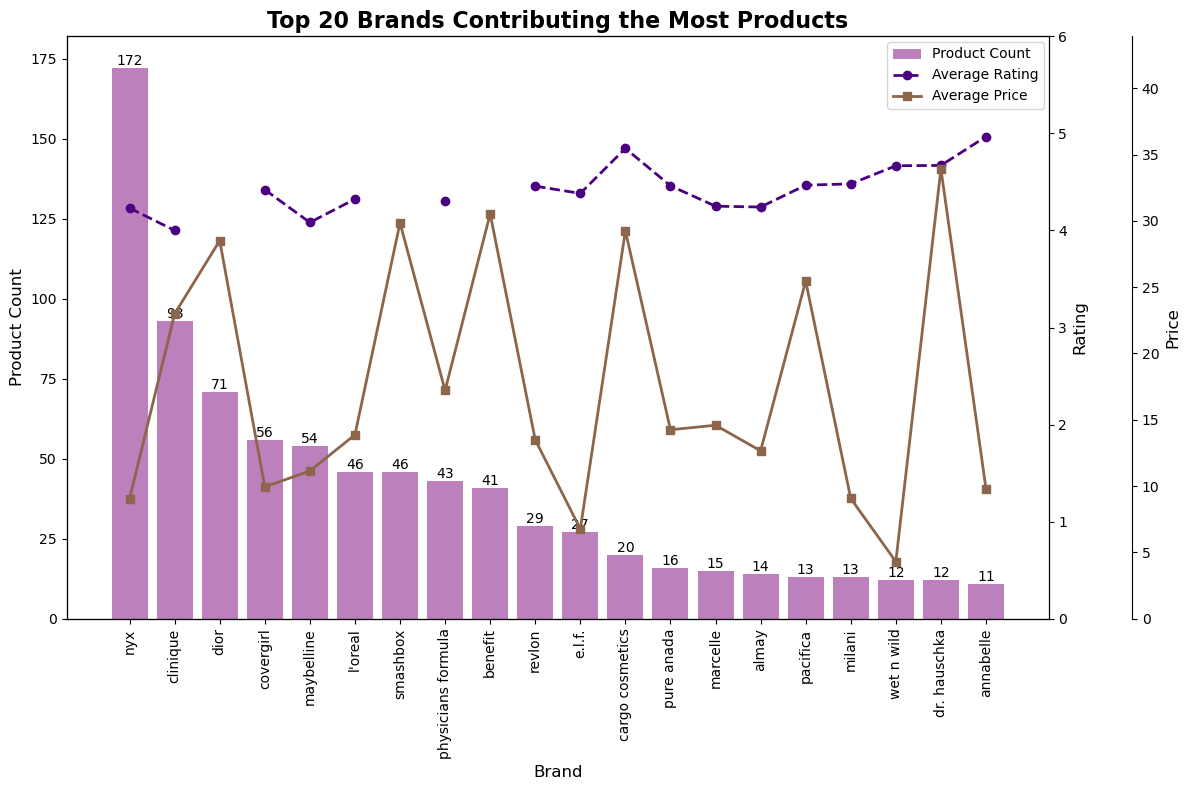

In [12]:
# 17. Top 20 Brands Offering the Most Products 

import pandas as pd
import matplotlib.pyplot as plt

# Load the data from the CSV file
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Count the number of products for each brand
brand_counts = df['brand'].value_counts()

# Select the top 20 brands by the number of products
selected_brands = brand_counts.head(20)

# Calculate the average rating and average price for the top 20 brands
average_ratings = df.groupby('brand')['rating'].mean().loc[selected_brands.index]
average_prices = df.groupby('brand')['price'].mean().loc[selected_brands.index]

# Create the chart
fig, ax1 = plt.subplots(figsize=(12, 8))

# Left axis (product count)
bars = ax1.bar(
    selected_brands.index,
    selected_brands.values,
    color='#bc80bd',  # Violet color as in the example
    label='Product Count'
)

# Add labels above the bars
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,  # Center the text above the bar
        bar.get_height(),  # Bar height
        f'{bar.get_height()}',  # Text showing the number of products
        ha='center',  # Horizontal alignment
        va='bottom',  # Vertical alignment
        fontsize=10,
        color='black'  # Black text
    )

ax1.set_xlabel("Brand", fontsize=12)
ax1.set_ylabel("Product Count", fontsize=12)
ax1.set_xticks(range(len(selected_brands.index)))
ax1.set_xticklabels(selected_brands.index, rotation=90)  # Vertical brand labels
ax1.set_ylim(0, selected_brands.max() + 10)

# Right axis (average rating)
ax2 = ax1.twinx()
ax2.plot(
    selected_brands.index,
    average_ratings,
    color='#4B0082',  # Indigo as in the example
    linestyle='--',  # Dashed line
    marker='o',  # Circle markers
    linewidth=2,
    label='Average Rating'
)
ax2.set_ylabel("Rating", fontsize=12)
ax2.set_ylim(0, 6)  # Scale for the rating

# Third axis (average price)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third axis
ax3.plot(
    selected_brands.index,
    average_prices,
    color='#8c654b',  # Brown color as in the example
    linestyle='-',  # Solid line
    marker='s',  # Square markers
    linewidth=2,
    label='Average Price'
)
ax3.set_ylabel("Price", fontsize=12)
ax3.set_ylim(0, average_prices.max() + 10)  # Scale for the price

# Add a legend slightly lower and to the left
fig.legend(
    loc='upper right',  # Place in the upper right corner
    bbox_to_anchor=(0.88, 0.95),  # Slightly lower and left
    fontsize=10
)

# Add a title with the number of brands
plt.title(f"Top 20 Brands Contributing the Most Products", fontsize=16, fontweight='bold')

# Finalize the chart layout
plt.tight_layout()

# Display the chart
plt.show()

# 17_Top_20_Brands_analysis


## 18. Price Distribution for Top 20 Leading Brands  

- **Chart Type:**  
    - `boxplot` (Boxplot).  
- **Displays:**  
   - **Price Distribution:** For each of the top 20 brands based on the prices of their products.  
   - **Median Prices:** Represented inside each box as a numerical value.  
- **Features:**  
   - The boxplot illustrates minimum and maximum prices, the first and third quartiles, as well as the median for each brand.  
   - The legend indicates that medians are displayed on the chart.


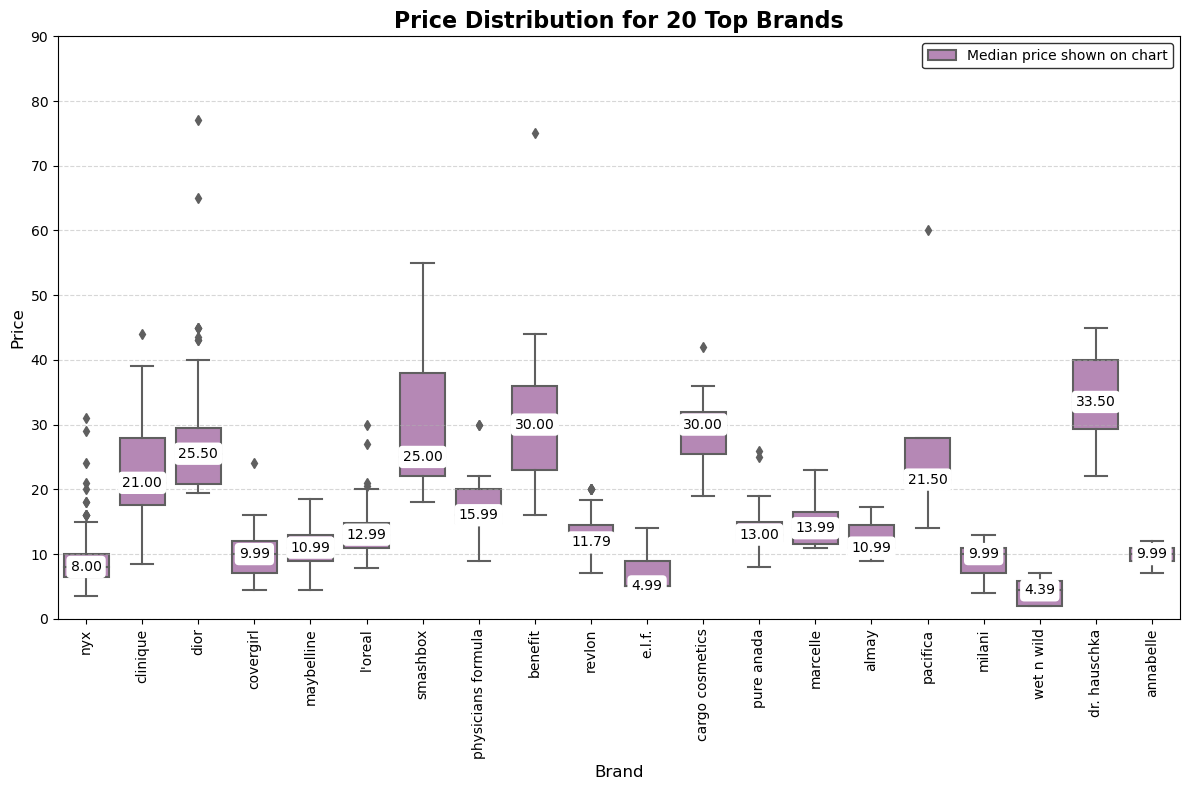

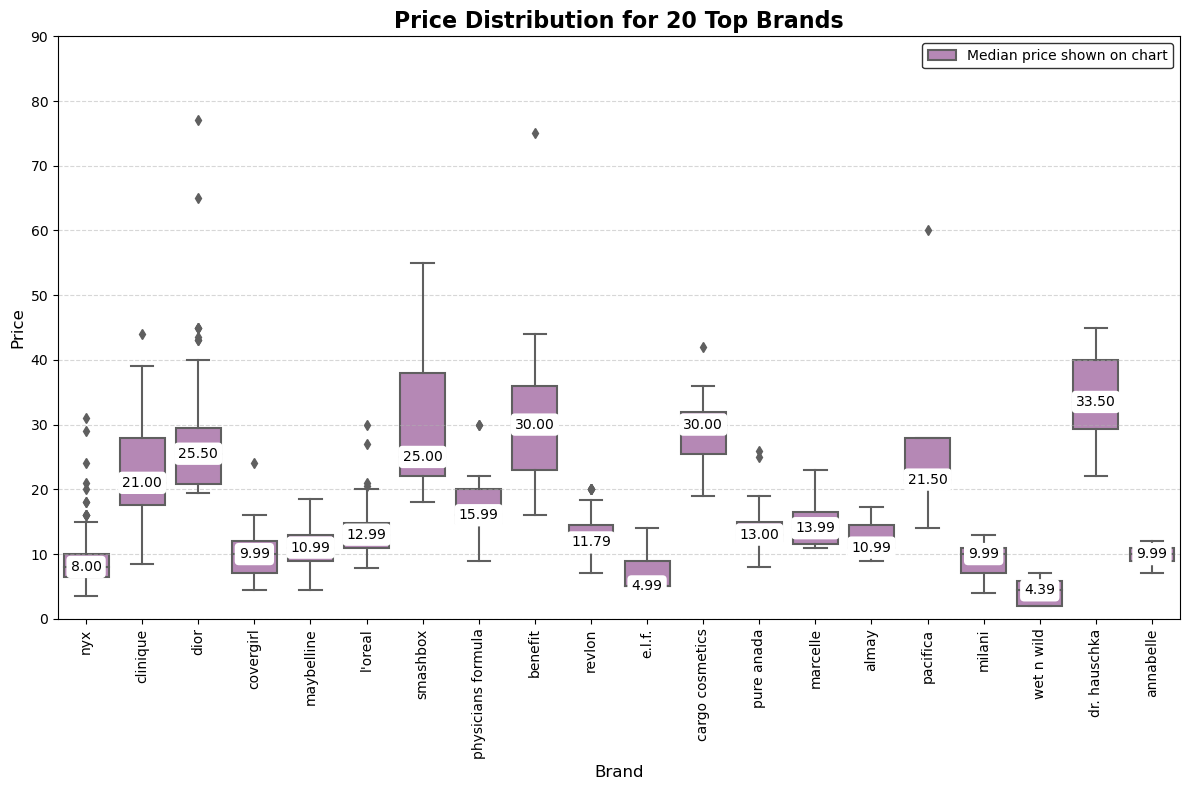

In [15]:
## 18. Price Distribution for Top 20 Leading Brands

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
file_path = "makeup_valid_prices_filled_columns.csv"
df = pd.read_csv(file_path)

# Count the number of products for each brand
brand_counts = df['brand'].value_counts()

# Select the top 20 brands based on the number of products
selected_brands = brand_counts.head(20)

# Filter the data for the selected brands
filtered_data = df[df['brand'].isin(selected_brands.index)]
median_prices = filtered_data.groupby('brand')['price'].median()

# Count the number of brands in the top 20
num_brands_top_20 = len(selected_brands)

# Create the boxplot
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=filtered_data,
    x='brand',
    y='price',
    order=selected_brands.index,  # Ordering of boxes
    color='#bc80bd'  # Violet color
)

# Add median text inside each box
for i, brand in enumerate(selected_brands.index):
    median_price = median_prices[brand]
    plt.text(
        i,  # Position on the X-axis
        median_price,  # Median level on the Y-axis
        f'{median_price:.2f}',  # Median text (2 decimal places)
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=10,
        color='black',
        bbox=dict(boxstyle="round,pad=0.3", edgecolor='none', facecolor='white')  # Background for readability
    )

# Add a legend with a white rectangle and black edges
legend = plt.legend(
    ["Median price shown on chart"],  # New legend text
    loc="upper right",  # Legend location
    fontsize=10,
    frameon=True  # Enable frame for the legend
)

# Style the legend frame
legend.get_frame().set_edgecolor('black')  

# Add the overall title
plt.title(f"Price Distribution for {num_brands_top_20} Top Brands", fontsize=16, fontweight='bold')

# Adjust the Y-axis scale
plt.ylim(0, 90)

# Style the chart
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=90)  # Vertical brand labels
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the chart
plt.show()

## 18_Top_20_Brands_Price_statistics


## 19. Price Category Distribution Among Top 20 Brands  

- **Chart Type:**  
   - Stacked bar chart.  
- **Displays:**  
   - Percentage distribution of products across different price categories (low, mid, high, premium) for the top 20 brands.  
   - This chart helps evaluate which brands are most active within each price category and compare brand strategies across different market segments.


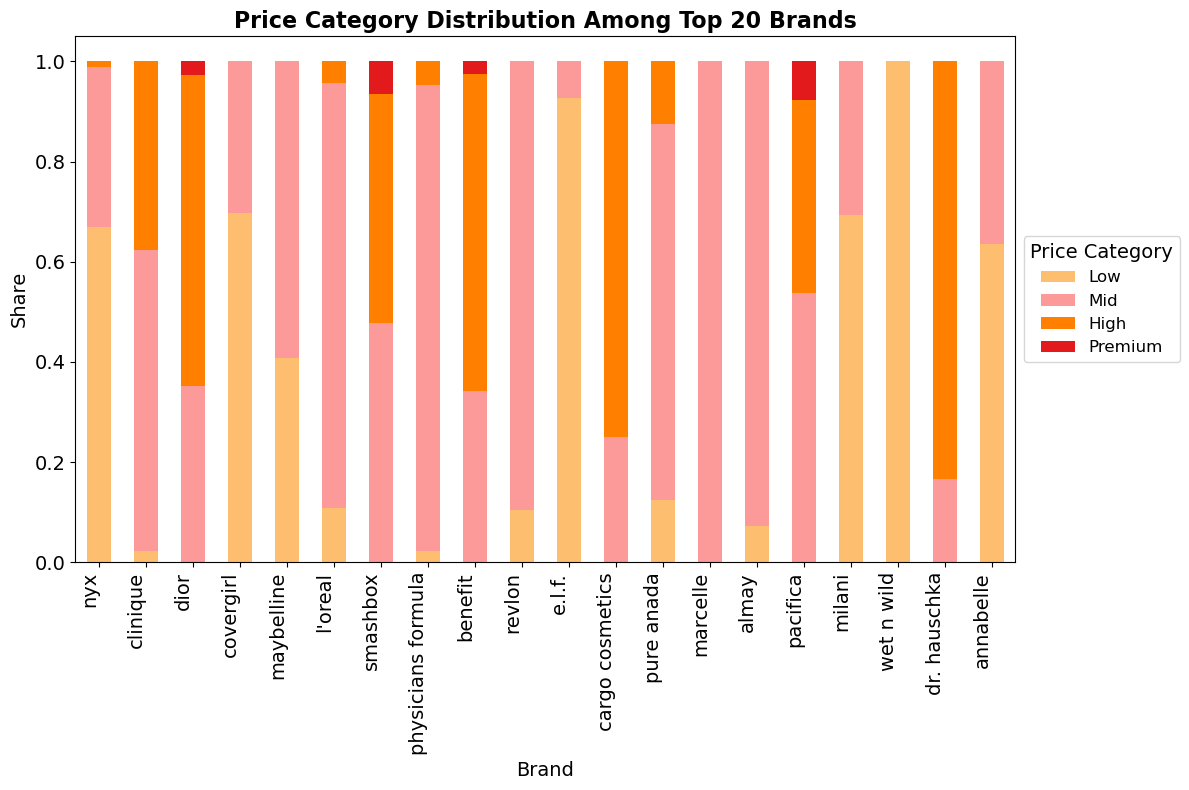

In [17]:
### 19. Price Category Distribution Among Top 20 Brands 

import pandas as pd
import matplotlib.pyplot as plt

# Get the top 20 brands by product count
top_20_brands = df['brand'].value_counts().head(20).index
df_top20 = df[df['brand'].isin(top_20_brands)]

# Group data by brand and price category
grouped = df_top20.groupby(['brand', 'price_category']).size().unstack(fill_value=0)

# Sort price categories by their order
price_order = ['low', 'mid', 'high', 'premium']
grouped = grouped[price_order]

# Convert counts to percentages
grouped_percent = grouped.div(grouped.sum(axis=1), axis=0)

# Define colors for each price category
color_map = {
    'low': '#fdbf6f',
    'mid': '#fb9a99',
    'high': '#ff7f00',
    'premium': '#e31a1c'
}

# Create stacked bar chart
ax = grouped_percent.loc[top_20_brands].plot(
    kind='bar',
    stacked=True,
    color=[color_map[col] for col in price_order],  # Ensures colors are displayed in the correct order
    figsize=(12, 8)
)

# Chart styling
plt.title('Price Category Distribution Among Top 20 Brands', fontsize=16, fontweight='bold')
plt.xlabel('Brand', fontsize=14)
plt.ylabel('Share', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=14)
plt.yticks(fontsize=14)

# Legend (displayed vertically on the right side)
handles, labels = ax.get_legend_handles_labels()
new_labels = [label.capitalize() for label in labels]
ax.legend(
    handles, new_labels, title='Price Category', title_fontsize=14, fontsize=12,
    loc='center left', bbox_to_anchor=(1.0, 0.5)  # Legend aligned to the center right
)

# Display the chart
plt.tight_layout()
plt.show()

## 19_Top_20_Brands_Price_Category


## 20. Distribution of Products Across Category-Product Types for Top 20 Brands  

- **Chart Type:**  
   - Heatmap.  
- **Displays:**  
   - The distribution of product counts for category-product types (`Category-product types`) among the top 20 brands.  
   - This chart allows easy evaluation of which brands are most active in different category-product types and highlights the connections between them.


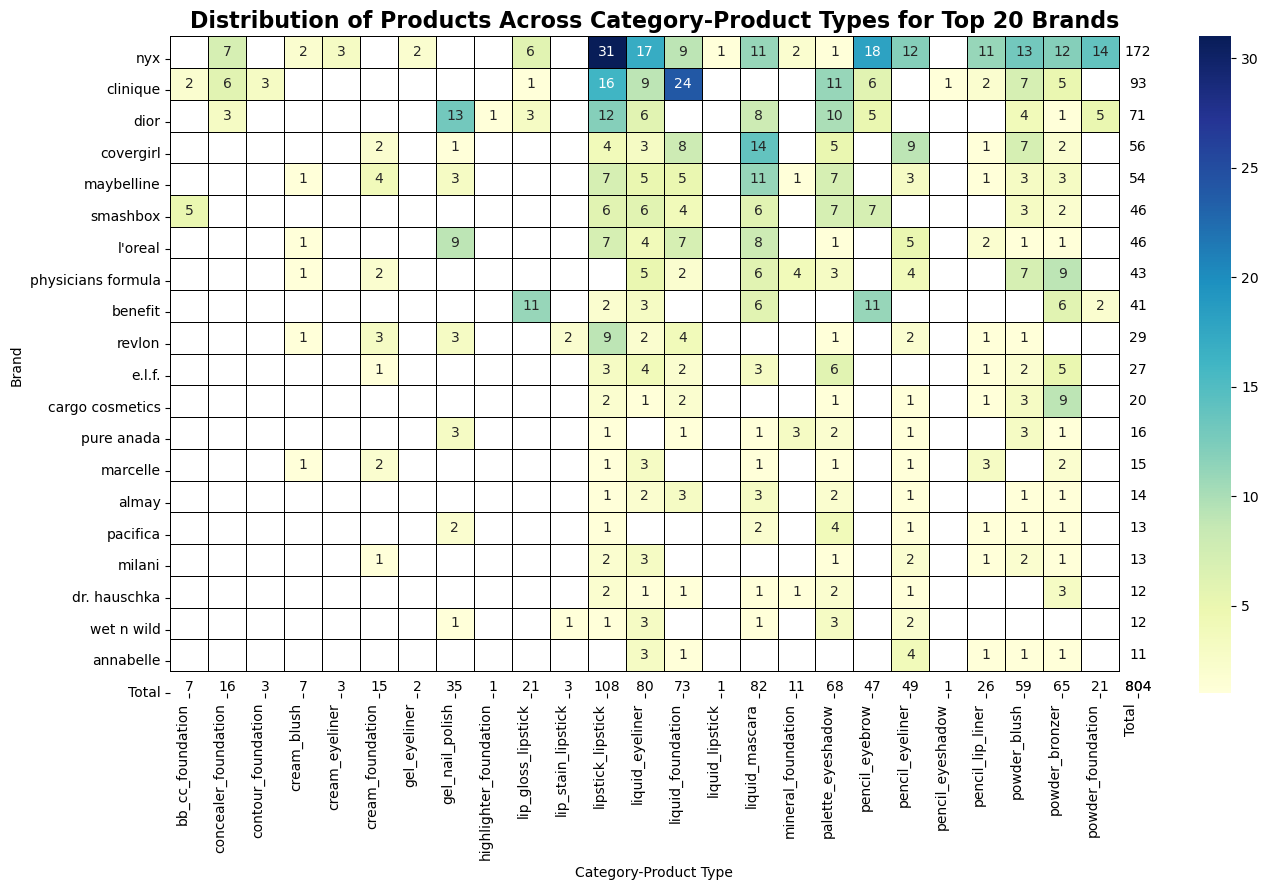

In [19]:
# 20. Distribution of Products Across Category-Product Types for Top 20 Brands 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv("makeup_valid_prices_filled_columns.csv")

# Count the number of products for each brand
bc = df['brand'].value_counts()

# Select the top 20 brands by product count
sel = bc.head(20).index

# Filter the data for the selected brands
f = df[df['brand'].isin(sel)]

# Count the number of products for each brand and category_product_type
counts = (
    f.groupby(['brand', 'category_product_type'])['id']
     .count()
     .unstack(fill_value=0)
)

# Add the total product counts to the table
counts.loc['Total'] = counts.sum()
counts['Total'] = counts.sum(axis=1)

# Sort brands by total product count
sorted_counts = counts.sort_values(by='Total', ascending=False)

core = sorted_counts.drop(index='Total', columns='Total')

# Prepare annotations without zeros
annot = sorted_counts.loc[core.index, core.columns].astype(str)
annot[annot == '0'] = ''

# Mask for coloring only non-zero values in the core data
mask = core == 0

# Heatmap of Brands, Categories, and Product Types in the Makeup Catalog
plt.figure(figsize=(14, 9))
ax = sns.heatmap(
    core,
    annot=annot,
    fmt="",  # Annotation as plain text
    cmap="YlGnBu",  # Color palette
    linewidths=0.5,
    linecolor="black",
    cbar=True,  # Include color bar
    mask=mask  # Apply mask to hide zeros
)

# Add labels to X and Y axes
xt = list(core.columns) + ['Total']
yt = list(core.index) + ['Total']

ax.set_xticks([i + 0.5 for i in range(len(xt))])
ax.set_xticklabels(xt, rotation=90, ha='right')  # Rotate X-axis labels
ax.set_yticks([i + 0.7 for i in range(len(yt))])
ax.set_yticklabels(yt, rotation=0)  # Keep Y-axis labels horizontal

# Add summary values to the heatmap
for i, col in enumerate(xt):
    v = sorted_counts.at['Total', col]
    ax.text(i + 0.5, len(core) + 0.5, v, ha='center', va='center')
for j, row in enumerate(yt):
    v = sorted_counts.at[row, 'Total']
    ax.text(len(core.columns) + 0.5, j + 0.5, v, ha='center', va='center')

# Add the title and finalize styling
plt.title("Distribution of Products Across Category-Product Types for Top 20 Brands", fontsize=16, fontweight='bold')
plt.xlabel("Category-Product Type")
plt.ylabel("Brand")
plt.tight_layout()

# Display the heatmap
plt.show()

# 20_Top_20_Brands_Across_Category_Product_Heatmap
